# Retail Store Sales Analysis using Python

### Business Performance Analysis of Brew Bite Outlets

**Author:** Neha Garg

**Tools Used:** Python, Pandas, NumPy, Matplotlib, Seaborn, Jupyter Notebook

# Project Objective

The objective of this project is to analyze the sales performance of Brew Bite retail outlets across different locations. The analysis focuses on understanding revenue trends, customer footfall, profitability, store performance, and operational efficiency using Python-based data analysis techniques.

The project aims to identify key business insights that can support data-driven decision making.

# Dataset Description

The dataset contains monthly sales records of Brew Bite retail outlets across multiple locations.

It includes information such as:

- Store Name
- Area
- Zone
- Store Format
- Store Size
- Opening Year
- Month
- Customer Footfall
- Orders
- Average Order Value
- Revenue
- Cost of Goods Sold (COGS)
- Marketing Spend
- Utilities
- Salaries
- Total Cost
- Profit

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as  sns

pd.set_option('display.max_columns', None)

In [30]:
df = pd.read_csv("S.csv")
print(df["month"].unique())

['2023-01' '2023-02' '2023-03' '2023-04' '2023-05' '2023-06' '2023-07'
 '2023-08' '2023-09' '2023-10' '2023-11' '2023-12' '2024-01' '2024-02'
 '2024-03' '2024-04' '2024-05' '2024-06' '2024-07' '2024-08']


In [3]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.info()

Rows: 1000
Columns: 21
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   record_id          1000 non-null   object 
 1   outlet_id          1000 non-null   object 
 2   outlet_name        1000 non-null   object 
 3   area               1000 non-null   object 
 4   zone               1000 non-null   object 
 5   store_format       1000 non-null   object 
 6   store_size_sqft    1000 non-null   int64  
 7   opening_year       1000 non-null   int64  
 8   month              1000 non-null   object 
 9   footfall           1000 non-null   int64  
 10  orders             1000 non-null   int64  
 11  avg_order_value    1000 non-null   int64  
 12  revenue            1000 non-null   int64  
 13  cogs               1000 non-null   int64  
 14  rent               1000 non-null   int64  
 15  salaries           1000 non-null   int64  
 16  ma

In [33]:
df["month"] = pd.to_datetime(df["month"])
print(df["month"].head())

0   2023-01-01
1   2023-02-01
2   2023-03-01
3   2023-04-01
4   2023-05-01
Name: month, dtype: datetime64[ns]


In [4]:
missing = df.isnull().sum()

missing = missing[missing > 0]

missing.sort_values(ascending=False)

Series([], dtype: int64)

In [6]:
df.fillna(df.mean(numeric_only=True), inplace=True)

In [7]:
duplicates = df.duplicated().sum()

print("Duplicate Rows:", duplicates)

Duplicate Rows: 0


In [8]:
df.dtypes

record_id             object
outlet_id             object
outlet_name           object
area                  object
zone                  object
store_format          object
store_size_sqft        int64
opening_year           int64
month                 object
footfall               int64
orders                 int64
avg_order_value        int64
revenue                int64
cogs                   int64
rent                   int64
salaries               int64
marketing_spend        int64
utilities              int64
total_cost             int64
profit                 int64
profit_margin_pct    float64
dtype: object

In [10]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
store_size_sqft,1000.0,9.248600e+02,350.109093,215.0,781.000,944.0,1154.00,1684.0
opening_year,1000.0,2.021560e+03,1.283763,2019.0,2021.000,2022.0,2023.00,2023.0
footfall,1000.0,6.451725e+03,2584.920495,1763.0,4616.000,6011.5,8338.25,16735.0
orders,1000.0,3.996511e+03,1670.761843,938.0,2825.750,3681.0,5182.50,10731.0
avg_order_value,1000.0,2.484930e+02,29.818503,175.0,228.000,246.0,267.00,365.0
revenue,1000.0,1.008827e+06,486881.402493,223220.0,661295.000,911255.0,1307577.50,3142090.0
cogs,1000.0,3.227688e+05,157107.700135,72877.0,212026.750,285141.0,418810.50,1015058.0
rent,1000.0,9.444000e+04,65701.944762,6800.0,49900.000,81050.0,123200.00,280900.0
salaries,1000.0,9.120930e+04,36743.352562,16500.0,71650.000,92300.0,113750.00,193000.0
marketing_spend,1000.0,5.010311e+04,28638.931131,6591.0,30040.000,44051.5,62807.50,224043.0


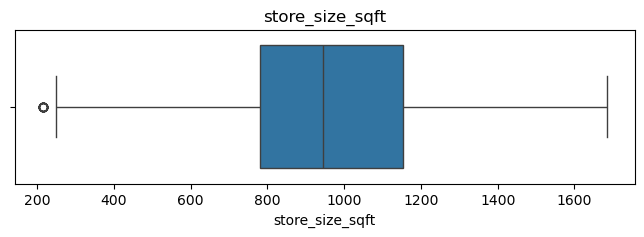

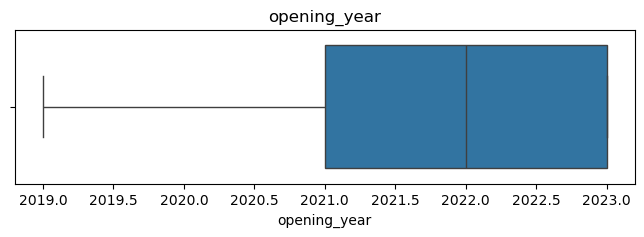

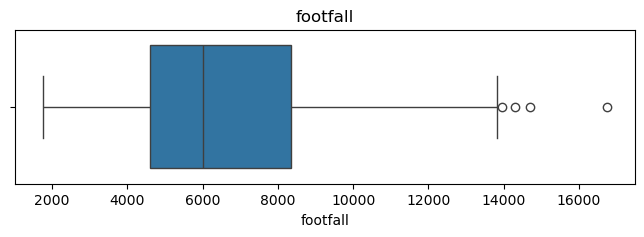

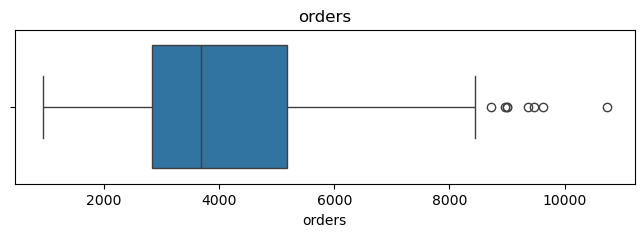

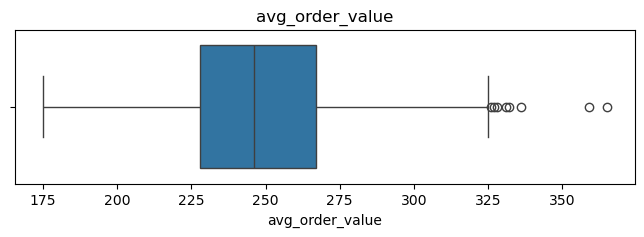

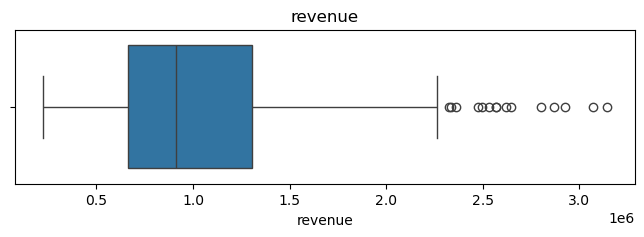

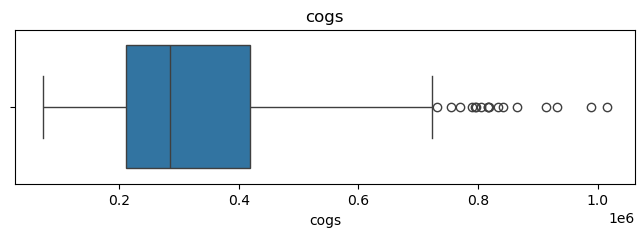

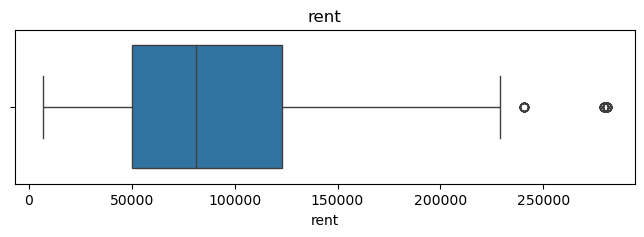

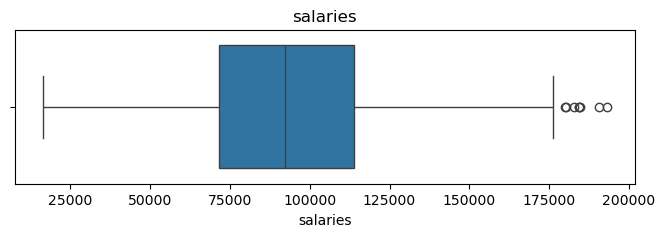

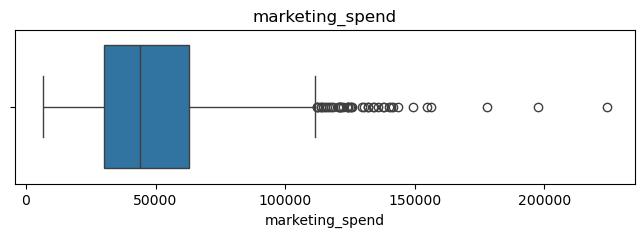

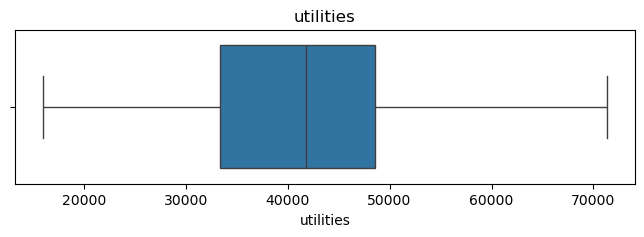

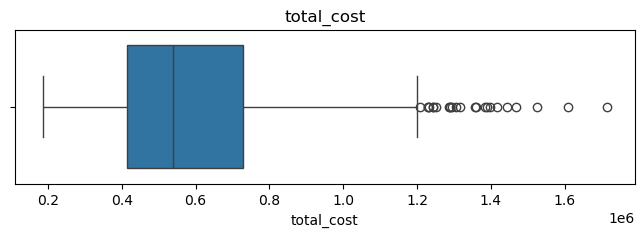

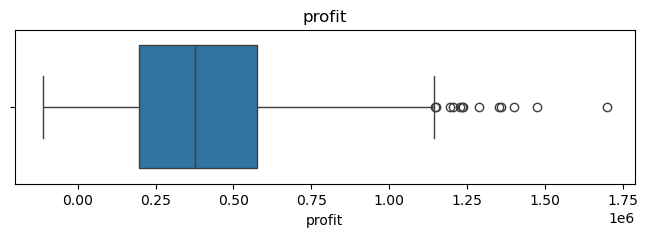

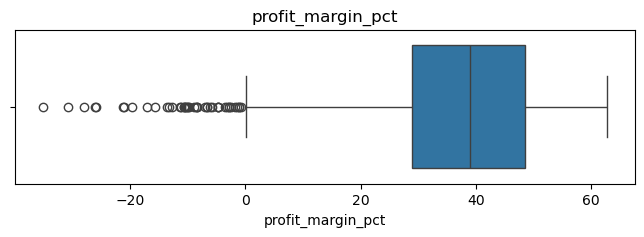

In [19]:
numeric = df.select_dtypes(include=np.number)

for col in numeric.columns:

    plt.figure(figsize=(8,2))

    sns.boxplot(x=df[col])

    plt.title(col)

    plt.show()

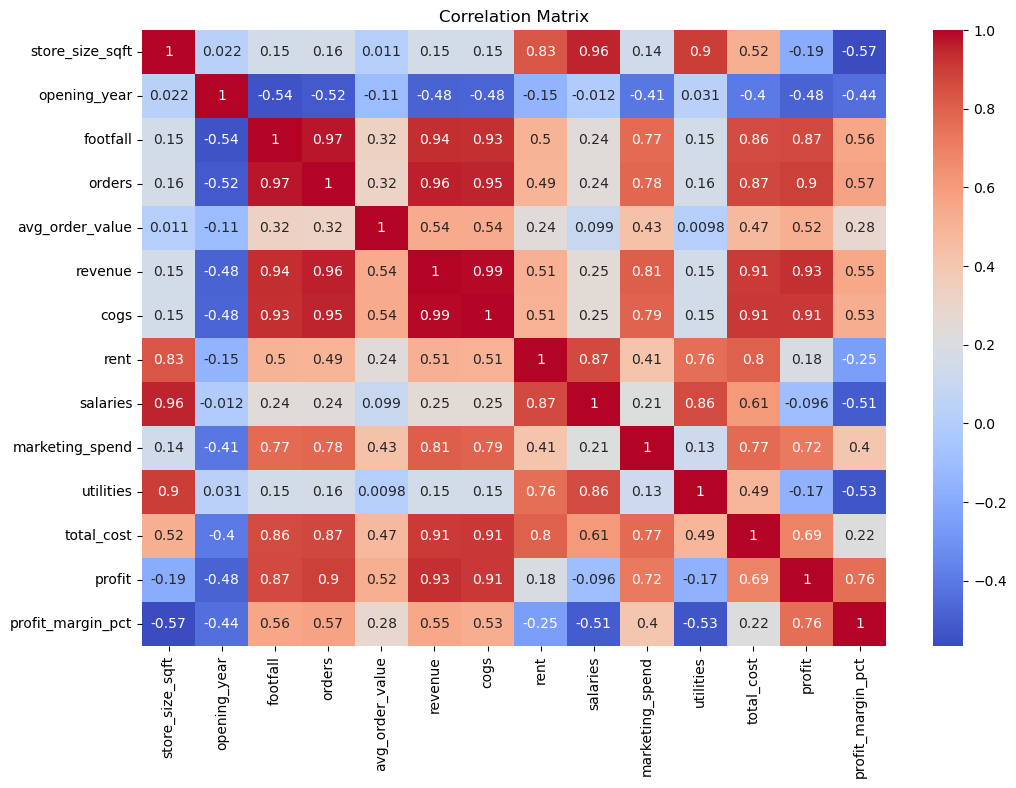

In [20]:
plt.figure(figsize=(12,8))

sns.heatmap(
    numeric.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

Exploratory Data Analysis


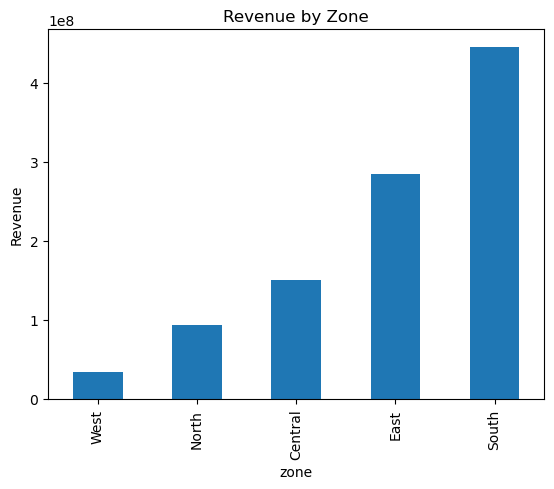

In [21]:
print("Exploratory Data Analysis")
zone = df.groupby("zone")["revenue"].sum().sort_values()

zone.plot(kind="bar")

plt.title("Revenue by Zone")

plt.ylabel("Revenue")

plt.show()

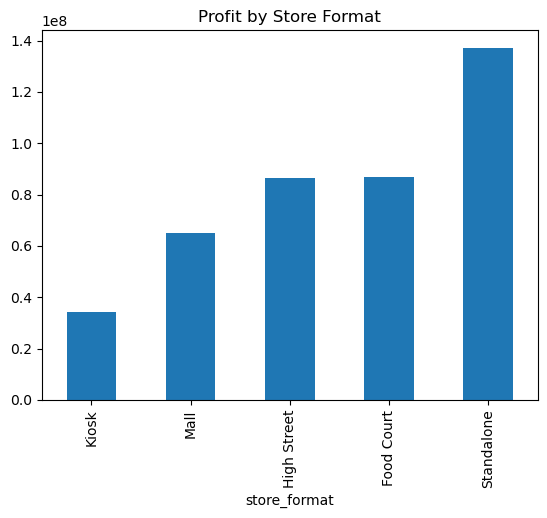

In [22]:
format_profit = (
    df.groupby("store_format")["profit"]
      .sum()
      .sort_values()
)

format_profit.plot(kind="bar")

plt.title("Profit by Store Format")

plt.show()

In [34]:
df["Month_Name"] = df["month"].dt.strftime("%b %Y")

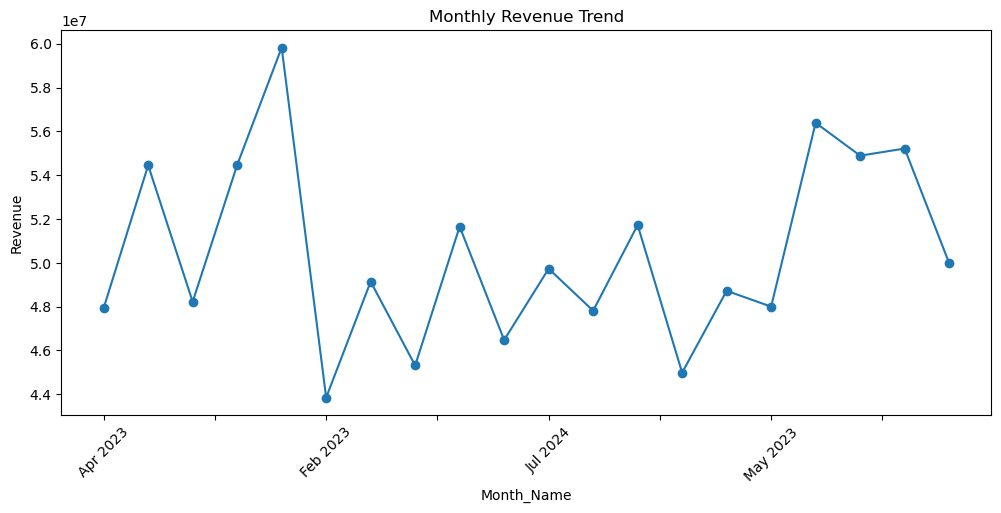

In [35]:
monthly = df.groupby("Month_Name")["revenue"].sum()

plt.figure(figsize=(12,5))

monthly.plot(marker="o")

plt.xticks(rotation=45)

plt.title("Monthly Revenue Trend")

plt.ylabel("Revenue")

plt.show()

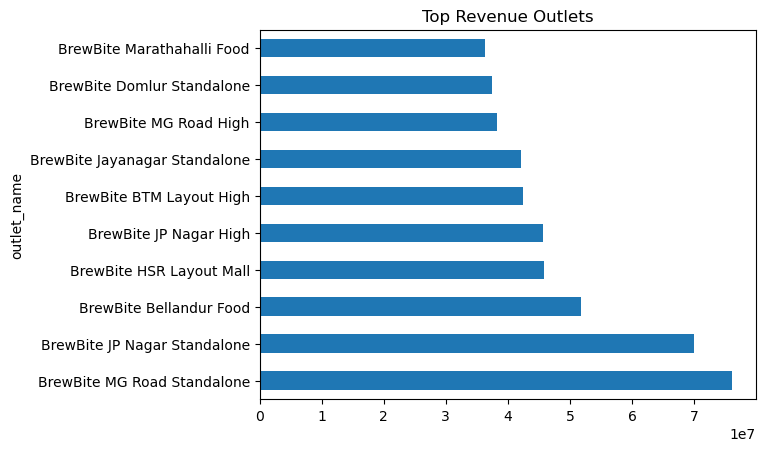

In [36]:
top = (
    df.groupby("outlet_name")["revenue"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

top.plot(kind="barh")

plt.title("Top Revenue Outlets")

plt.show()

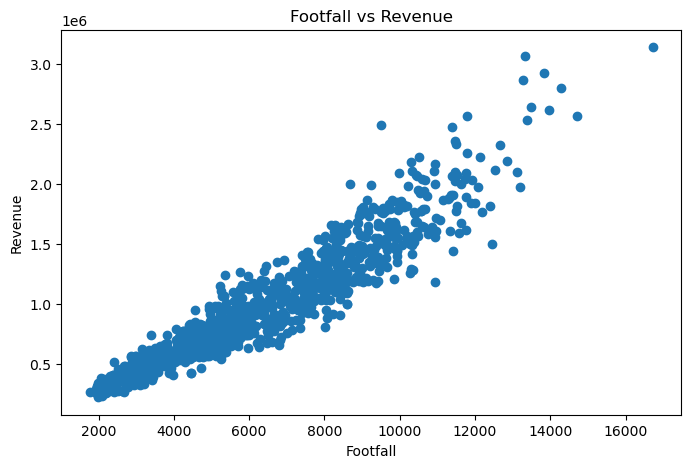

In [37]:
plt.figure(figsize=(8,5))

plt.scatter(
    df["footfall"],
    df["revenue"]
)

plt.xlabel("Footfall")

plt.ylabel("Revenue")

plt.title("Footfall vs Revenue")

plt.show()

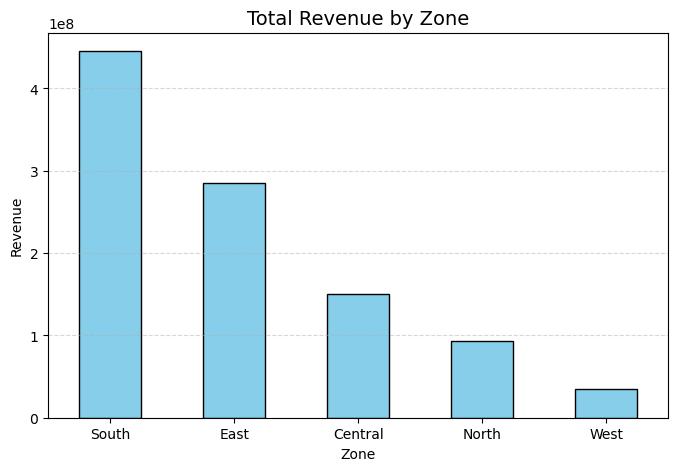

In [79]:
plt.figure(figsize=(8,5))

zone_revenue.plot(
    kind="bar",
    color="skyblue",
    edgecolor="black"
)

plt.title("Total Revenue by Zone", fontsize=14)
plt.xlabel("Zone")
plt.ylabel("Revenue")
plt.xticks(rotation=0)

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()


In [ ]:
### Business Insight

- South zone generated the highest revenue (₹445.44 million), indicating strong sales performance.
- East zone ranked second, showing consistent customer demand.
- West zone generated the lowest revenue and may benefit from additional marketing campaigns or operational improvements.
    

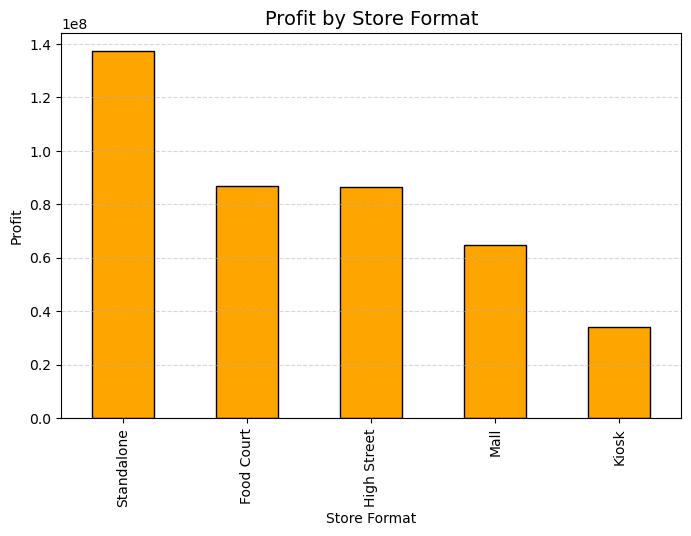

The Standalone format generated the highest overall profit.


In [45]:
store_profit = (
    df.groupby("store_format")["profit"]
      .sum()
      .sort_values(ascending=False)
)

store_profit

plt.figure(figsize=(8,5))

store_profit.plot(
    kind="bar",
    color="orange",
    edgecolor="black"
)

plt.title("Profit by Store Format", fontsize=14)
plt.xlabel("Store Format")
plt.ylabel("Profit")

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

best_format = store_profit.idxmax()

print(f"The {best_format} format generated the highest overall profit.")

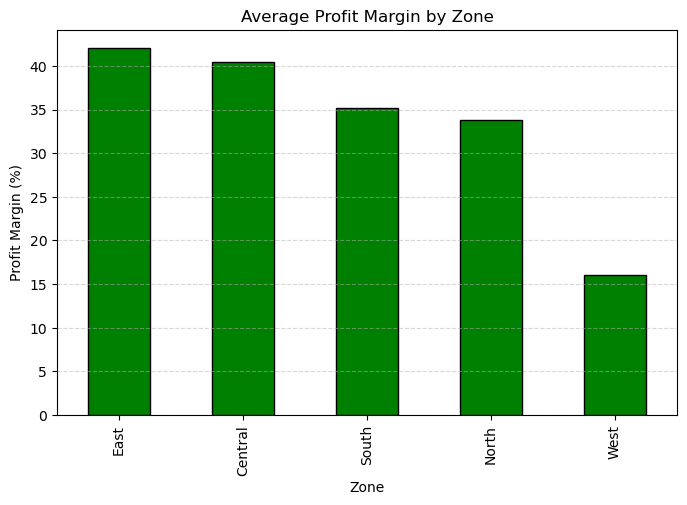

East has the highest average profit margin.


In [46]:
zone_margin = (
    df.groupby("zone")["profit_margin_pct"]
      .mean()
      .sort_values(ascending=False)
)

zone_margin

plt.figure(figsize=(8,5))

zone_margin.plot(
    kind="bar",
    color="green",
    edgecolor="black"
)

plt.title("Average Profit Margin by Zone")
plt.xlabel("Zone")
plt.ylabel("Profit Margin (%)")

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

best_zone = zone_margin.idxmax()

print(f"{best_zone} has the highest average profit margin.")

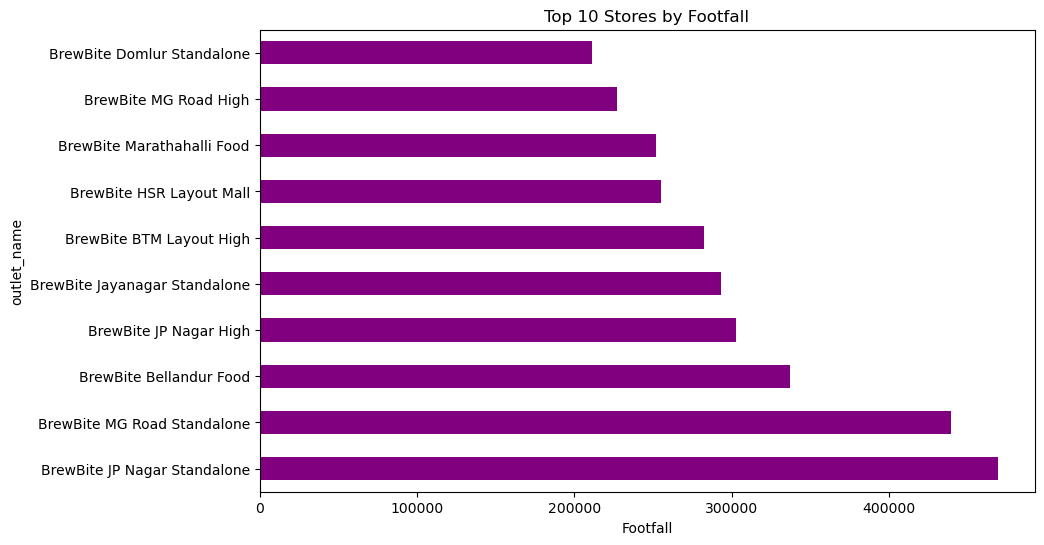

In [47]:
top_footfall = (
    df.groupby("outlet_name")["footfall"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

top_footfall

plt.figure(figsize=(10,6))

top_footfall.plot(
    kind="barh",
    color="purple"
)

plt.title("Top 10 Stores by Footfall")

plt.xlabel("Footfall")

plt.show()

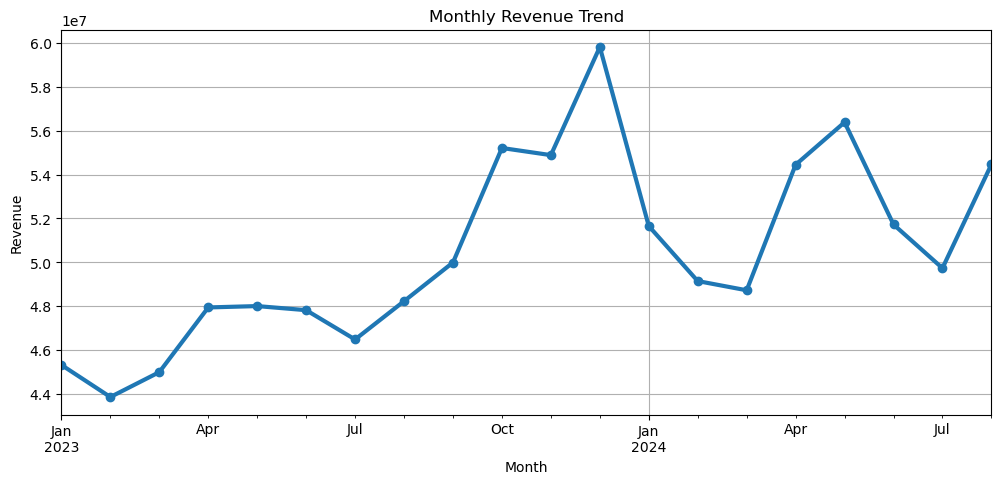

In [48]:
df["month"] = pd.to_datetime(df["month"])

monthly = (
    df.groupby("month")["revenue"]
      .sum()
)

plt.figure(figsize=(12,5))

monthly.plot(
    marker="o",
    linewidth=3
)

plt.title("Monthly Revenue Trend")

plt.xlabel("Month")

plt.ylabel("Revenue")

plt.grid(True)

plt.show()

# Feature Engineering

### Revenue per Customer

This KPI measures the average revenue generated from each customer visit. It helps identify how much customers spend on average.

In [59]:
df["Revenue_per_Customer"] = df["revenue"] / df["footfall"]

df[["revenue","footfall","Revenue_per_Customer"]].head()

,revenue,footfall,Revenue_per_Customer
0,683550,5652,120.939490
1,881480,5915,149.024514
2,843640,6870,122.800582
3,757080,7016,107.907640
4,808460,8028,100.705032


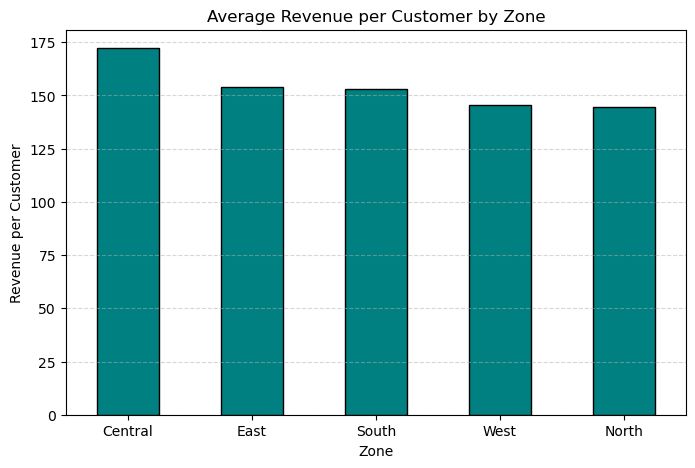

In [62]:
rpc = (
    df.groupby("zone")["Revenue_per_Customer"]
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))

rpc.plot(kind="bar", color="teal", edgecolor="black")

plt.title("Average Revenue per Customer by Zone")
plt.xlabel("Zone")
plt.ylabel("Revenue per Customer")
plt.xticks(rotation=0)

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

### Business Insight

- South generated the highest total revenue during the observed period.
- Customers in this zone spend more per visit.
- The business can study pricing or product mix in this zone and apply successful strategies to other regions.


## Profit per Order

This KPI measures the average profit earned from each customer order. It helps identify which store formats generate higher profitability per transaction.

In [50]:
df["Profit_per_Order"] = df["profit"] / df["orders"]

df[["profit","orders","Profit_per_Order"]].head()

,profit,orders,Profit_per_Order
0,200859,3001,66.930690
1,363019,3316,109.474970
2,300490,3561,84.383600
3,252555,3406,74.150029
4,309543,4285,72.238740


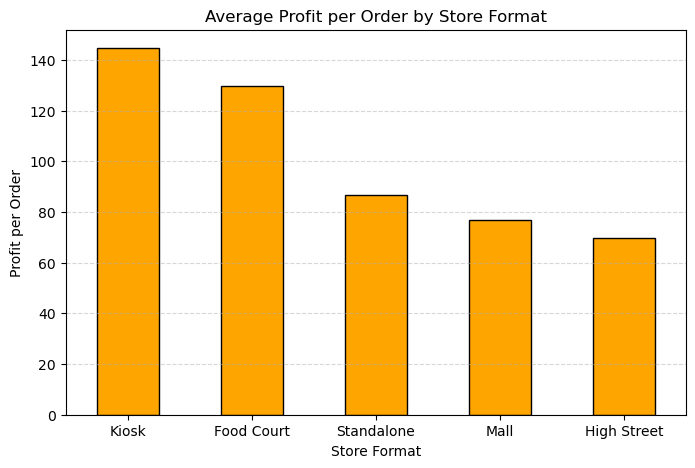

The Kiosk store format has the highest average profit per order.


In [68]:
ppo = (
    df.groupby("store_format")["Profit_per_Order"]
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))

ppo.plot(kind="bar", color="orange", edgecolor="black")

plt.title("Average Profit per Order by Store Format")
plt.xlabel("Store Format")
plt.ylabel("Profit per Order")
plt.xticks(rotation=0)

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()
best_format = ppo.idxmax()

print(f"The {best_format} store format has the highest average profit per order.")

## Cost per Order

This KPI measures the average operational cost incurred for each customer order. It helps evaluate cost efficiency across different store formats.

In [51]:
df["Cost_per_Order"] = df["total_cost"] / df["orders"]

df[["total_cost","orders","Cost_per_Order"]].head()

,total_cost,orders,Cost_per_Order
0,482691,3001,160.843386
1,518461,3316,156.351327
2,543150,3561,152.527380
3,504525,3406,148.128303
4,498917,4285,116.433372


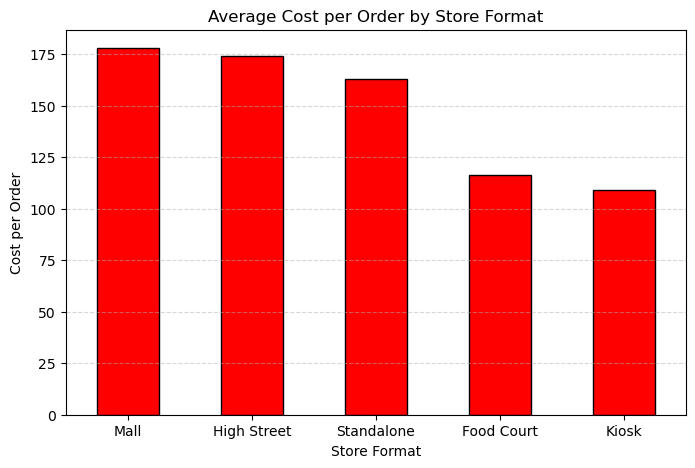

The Mall store format has the highest average cost per order.


In [69]:
cpo = (
    df.groupby("store_format")["Cost_per_Order"]
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))

cpo.plot(kind="bar", color="red", edgecolor="black")

plt.title("Average Cost per Order by Store Format")
plt.xlabel("Store Format")
plt.ylabel("Cost per Order")
plt.xticks(rotation=0)

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()
highest_cost = cpo.idxmax()

print(f"The {highest_cost} store format has the highest average cost per order.")

## Revenue per Square Foot

Revenue per Square Foot measures how efficiently a store utilizes its available floor space to generate sales.

In [55]:
df["Revenue_per_sqft"] = (
    df["revenue"] / df["store_size_sqft"]
)

df[["store_size_sqft","Revenue_per_sqft"]].head()

,store_size_sqft,Revenue_per_sqft
0,979,698.212462
1,979,900.388151
2,979,861.736466
3,979,773.319714
4,979,825.801839


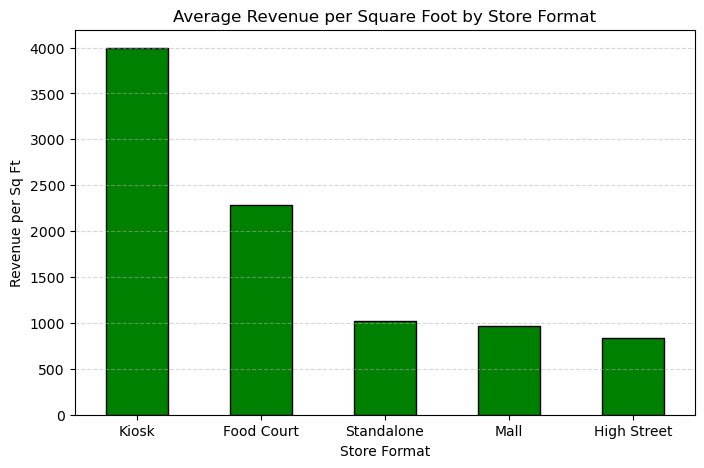

The Kiosk store format generates the highest revenue per square foot.


In [70]:
rps = (
    df.groupby("store_format")["Revenue_per_sqft"]
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))

rps.plot(kind="bar", color="green", edgecolor="black")

plt.title("Average Revenue per Square Foot by Store Format")
plt.xlabel("Store Format")
plt.ylabel("Revenue per Sq Ft")
plt.xticks(rotation=0)

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()
best_sqft = rps.idxmax()

print(f"The {best_sqft} store format generates the highest revenue per square foot.")

# Correlation Analysis

Correlation analysis helps identify the strength and direction of the relationship between numerical variables. This can reveal which factors are most closely associated with revenue, profit, and other business metrics.

In [71]:
numeric_df = df.select_dtypes(include=["number"])

numeric_df.head()

,store_size_sqft,opening_year,footfall,orders,avg_order_value,revenue,cogs,rent,salaries,marketing_spend,utilities,total_cost,profit,profit_margin_pct,Revenue_per_Customer,Profit_per_Order,Cost_per_Order,Revenue_per_sqft,Store_Age
0,979,2022,5652,3001,228,683550,221480,83200,92700,40111,45200,482691,200859,29.4,120.939490,66.930690,160.843386,698.212462,3
1,979,2022,5915,3316,266,881480,277421,83200,83000,29340,45500,518461,363019,41.2,149.024514,109.474970,156.351327,900.388151,3
2,979,2022,6870,3561,237,843640,274419,83200,97900,46531,41100,543150,300490,35.6,122.800582,84.383600,152.527380,861.736466,3
3,979,2022,7016,3406,222,757080,231879,83200,100800,49846,38800,504525,252555,33.4,107.907640,74.150029,148.128303,773.319714,3
4,979,2022,8028,4285,189,808460,257207,83200,93600,33210,31700,498917,309543,38.3,100.705032,72.238740,116.433372,825.801839,3


In [72]:
corr_matrix = numeric_df.corr()

corr_matrix

,store_size_sqft,opening_year,footfall,orders,avg_order_value,revenue,cogs,rent,salaries,marketing_spend,utilities,total_cost,profit,profit_margin_pct,Revenue_per_Customer,Profit_per_Order,Cost_per_Order,Revenue_per_sqft,Store_Age
store_size_sqft,1.000000,0.022490,0.153093,0.157313,0.011198,0.152930,0.154981,0.834330,0.955487,0.139309,0.898348,0.521717,-0.189627,-0.566117,0.047821,-0.506701,0.591155,-0.661218,-0.022490
opening_year,0.022490,1.000000,-0.536612,-0.515591,-0.110536,-0.481466,-0.479991,-0.153337,-0.012188,-0.407179,0.030947,-0.395757,-0.483952,-0.438386,-0.090661,-0.423005,0.400909,-0.300703,-1.000000
footfall,0.153093,-0.536612,1.000000,0.970049,0.322658,0.938548,0.927981,0.501623,0.236970,0.770328,0.150551,0.859399,0.867158,0.558666,0.277834,0.592048,-0.433076,0.445518,0.536612
orders,0.157313,-0.515591,0.970049,1.000000,0.316379,0.962833,0.951786,0.493717,0.239299,0.783263,0.155873,0.874601,0.895696,0.568287,0.412828,0.598492,-0.445362,0.458885,0.515591
avg_order_value,0.011198,-0.110536,0.322658,0.316379,1.000000,0.540407,0.537076,0.238788,0.099448,0.430839,0.009810,0.472740,0.518456,0.284168,0.785026,0.515324,0.173449,0.296840,0.110536
revenue,0.152930,-0.481466,0.938548,0.962833,0.540407,1.000000,0.989161,0.510663,0.249791,0.808569,0.150625,0.907309,0.931184,0.550670,0.565999,0.645410,-0.327749,0.475092,0.481466
cogs,0.154981,-0.479991,0.927981,0.951786,0.537076,0.989161,1.000000,0.505606,0.250267,0.794904,0.153896,0.911512,0.908921,0.527203,0.561522,0.622349,-0.303777,0.465151,0.479991
rent,0.834330,-0.153337,0.501623,0.493717,0.238788,0.510663,0.505606,1.000000,0.867036,0.413739,0.757873,0.802611,0.181359,-0.249021,0.225587,-0.164909,0.372634,-0.319985,0.153337
salaries,0.955487,-0.012188,0.236970,0.239299,0.099448,0.249791,0.250267,0.867036,1.000000,0.214274,0.863155,0.605190,-0.095608,-0.505036,0.117200,-0.429558,0.569871,-0.580550,0.012188
marketing_spend,0.139309,-0.407179,0.770328,0.783263,0.430839,0.808569,0.794904,0.413739,0.214274,1.000000,0.125782,0.773079,0.718717,0.401535,0.440044,0.476722,-0.217745,0.359651,0.407179


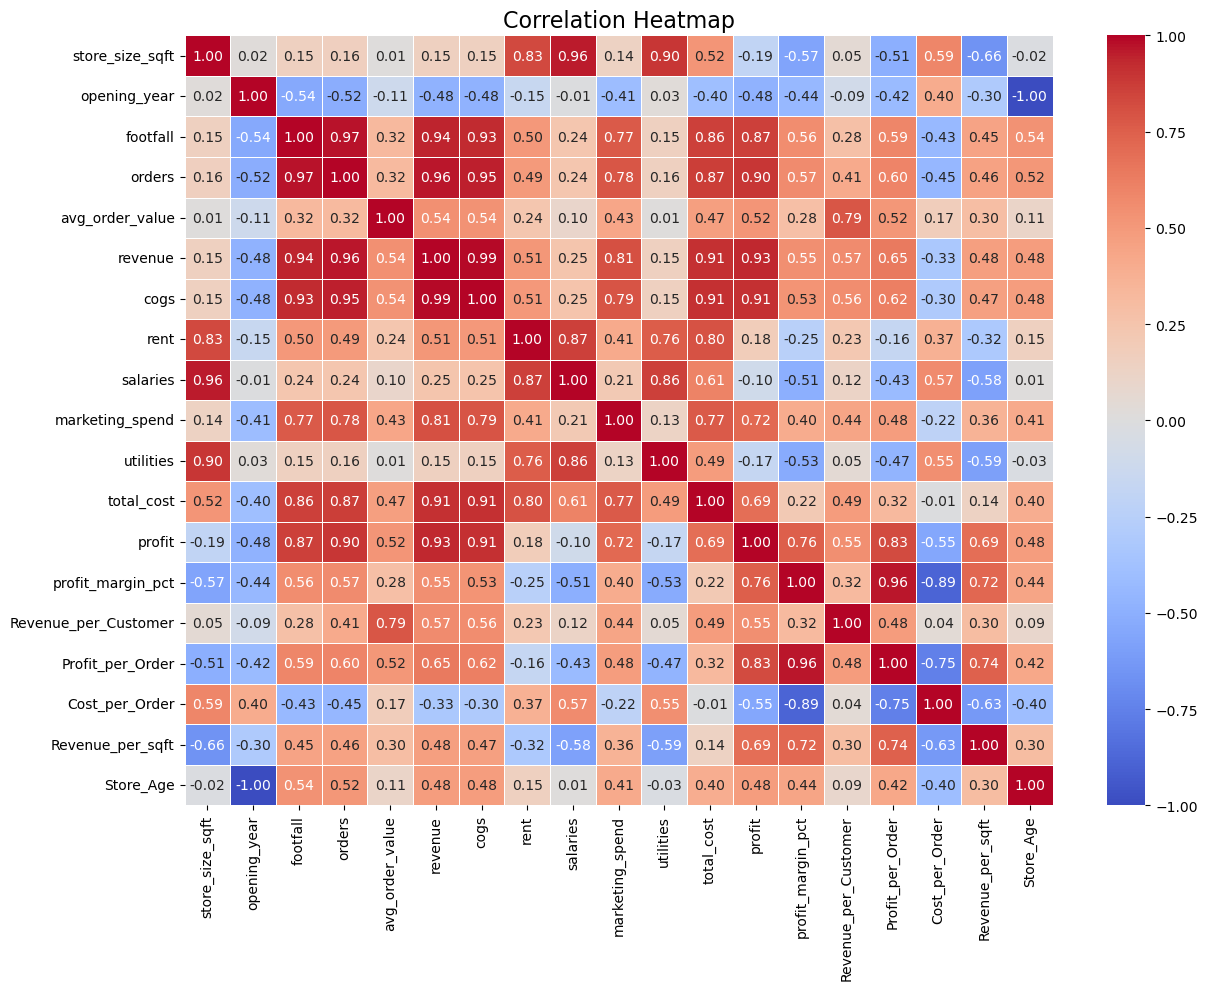

In [78]:
plt.figure(figsize=(14,10))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap", fontsize=16)

plt.show()

## Key Insights

- Revenue is strongly correlated with Orders.
- Revenue is strongly correlated with Footfall.
- Marketing Spend shows a positive relationship with Revenue.
- Cost per Order has a negative relationship with Revenue.

In [74]:
revenue_corr = corr_matrix["revenue"].sort_values(ascending=False)

print(revenue_corr)

revenue                 1.000000
cogs                    0.989161
orders                  0.962833
footfall                0.938548
profit                  0.931184
total_cost              0.907309
marketing_spend         0.808569
Profit_per_Order        0.645410
Revenue_per_Customer    0.565999
profit_margin_pct       0.550670
avg_order_value         0.540407
rent                    0.510663
Store_Age               0.481466
Revenue_per_sqft        0.475092
salaries                0.249791
store_size_sqft         0.152930
utilities               0.150625
Cost_per_Order         -0.327749
opening_year           -0.481466
Name: revenue, dtype: float64


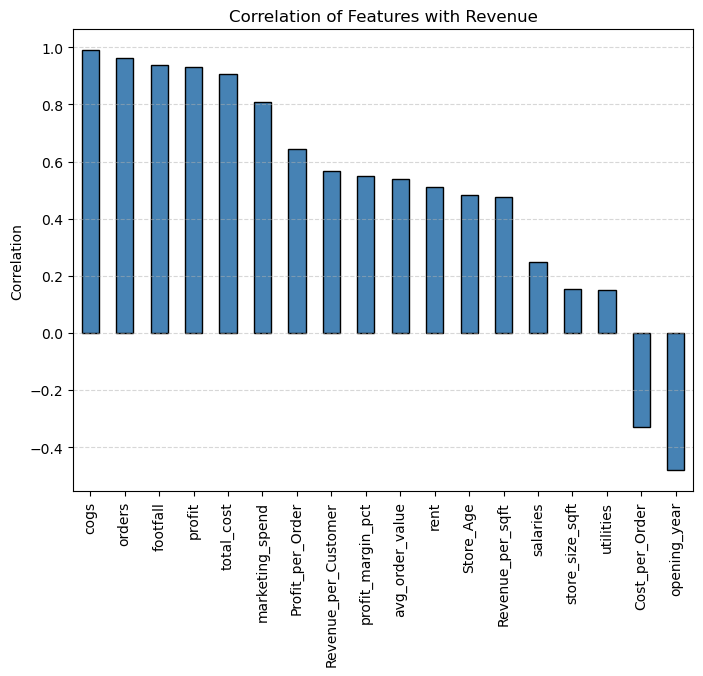

In [75]:
plt.figure(figsize=(8,6))

revenue_corr.drop("revenue").plot(
    kind="bar",
    color="steelblue",
    edgecolor="black"
)

plt.title("Correlation of Features with Revenue")
plt.ylabel("Correlation")

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

In [76]:
profit_corr = corr_matrix["profit"].sort_values(ascending=False)

print(profit_corr)

profit                  1.000000
revenue                 0.931184
cogs                    0.908921
orders                  0.895696
footfall                0.867158
Profit_per_Order        0.827882
profit_margin_pct       0.757031
marketing_spend         0.718717
Revenue_per_sqft        0.694394
total_cost              0.691592
Revenue_per_Customer    0.547226
avg_order_value         0.518456
Store_Age               0.483952
rent                    0.181359
salaries               -0.095608
utilities              -0.165894
store_size_sqft        -0.189627
opening_year           -0.483952
Cost_per_Order         -0.554344
Name: profit, dtype: float64


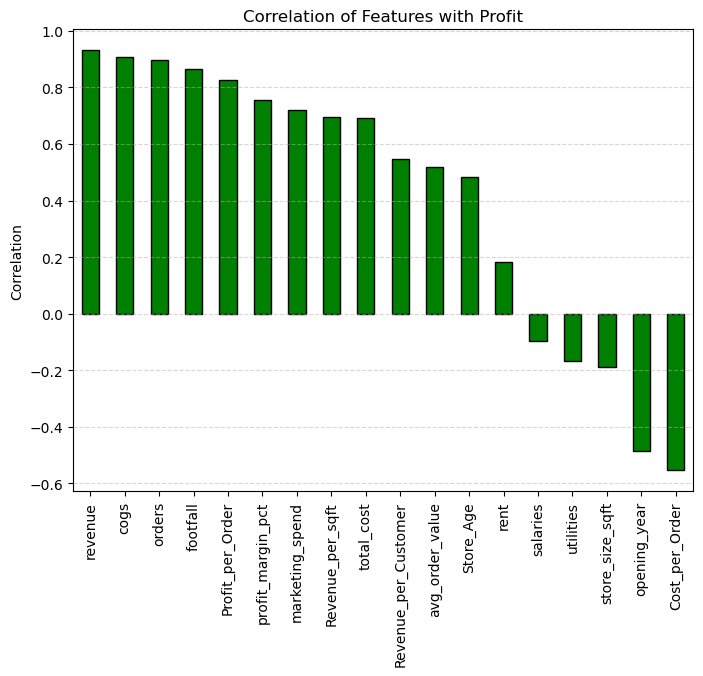

In [77]:
plt.figure(figsize=(8,6))

profit_corr.drop("profit").plot(
    kind="bar",
    color="green",
    edgecolor="black"
)

plt.title("Correlation of Features with Profit")
plt.ylabel("Correlation")

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

## Understanding Correlation

- Correlation values range from **-1 to +1**.
- A value close to **+1** indicates a strong positive relationship.
- A value close to **-1** indicates a strong negative relationship.
- A value close to **0** indicates little or no linear relationship.

# Project Summary

This project analyzes retail store performance using sales, customer, and operational data. The analysis focuses on identifying factors affecting revenue and profitability through data cleaning, exploratory data analysis, feature engineering, and correlation analysis.

# Key Findings

1. South zone generated the highest revenue.

2. Revenue increased during several months, indicating periods of stronger sales.

3. Revenue is strongly associated with customer footfall and orders.

4. Revenue per Customer varies across stores, highlighting differences in customer spending.

5. Revenue per Square Foot helps evaluate store space utilization.

6. Profit per Order identifies the efficiency of each transaction.

# Business Recommendations

- Increase customer footfall in lower-performing zones.
- Analyze why South zone performs better and replicate successful strategies.
- Monitor cost per order to improve profitability.
- Evaluate marketing effectiveness based on sales performance.

# Technologies Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Jupyter Notebook

# Conclusion

This project analyzed the sales performance of Brew Bite retail outlets using Python.

The analysis involved data cleaning, exploratory data analysis, feature engineering, and correlation analysis to identify trends and business insights.

The findings can support better decision-making in areas such as revenue growth, customer engagement, operational efficiency, and overall business performance.